In [3]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://www.worldometers.info/world-population/population-by-country/"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

table = soup.find("table", {"class": "datatable"})

rows = table.find_all("tr")[1:]

countries = []

for row in rows:
    cols = row.find_all("td")

    country_details = {
        "Country": cols[1].text.strip(),
        "Population": cols[2].text.strip(),
        "Yearly Change": cols[3].text.strip(),
        "Density": cols[5].text.strip()
    }
    countries.append(country_details)

df = pd.DataFrame(countries)

df["Population"] = df["Population"].str.replace(",", "").astype(int)

df["Density"] = df["Density"].str.replace(",", "").astype(int)

df["Yearly Change"] = (
    df["Yearly Change"]
    .str.replace("%", "")
    .str.replace("-", "-")
    .str.replace("â", "-")
    .astype(float)
)


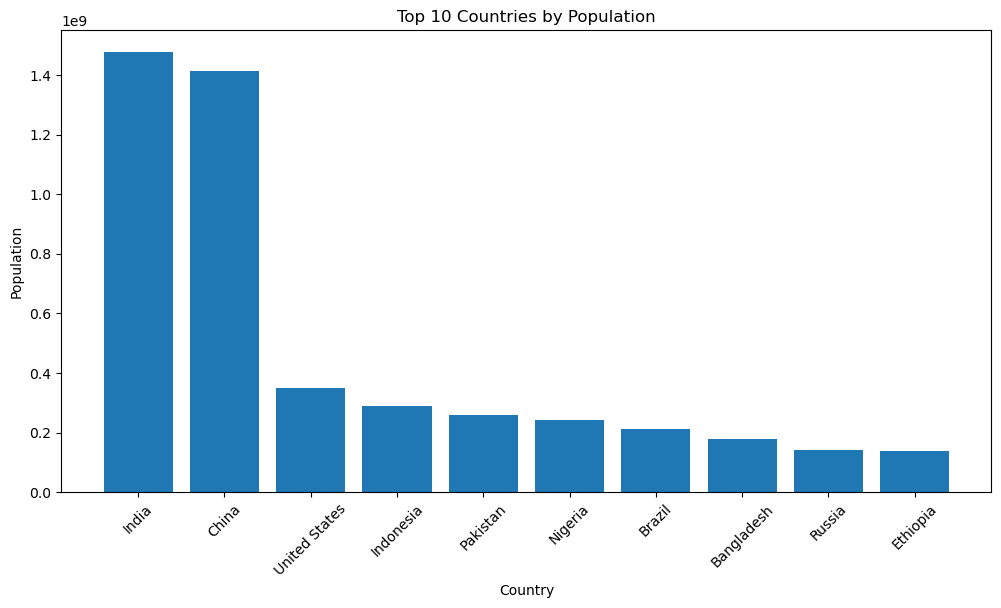

In [6]:
import matplotlib.pyplot as plt

top10 = df.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["Country"], top10["Population"])

plt.title("Top 10 Countries by Population")
plt.xlabel("Country")
plt.ylabel("Population")

plt.xticks(rotation=45)
plt.show()